# Point Processes in Biology: Epidemiology, Ecology, and Cell Biology

**A practical tutorial using `intensify` for quantitative biologists**

---

## Why point processes matter in biology

Across biology, we repeatedly encounter **events occurring at irregular times in continuous time**:

- **Epidemiology**: disease case reports arrive day by day, each infection potentially triggering secondary cases
- **Ecology**: animal vocalizations, predator sightings, and territorial displays occur in bursts
- **Cell biology**: calcium sparks, action potentials, and transcriptional bursts are discrete events with complex temporal dependence
- **Genomics**: mRNA production events cluster into bursts driven by promoter switching

The simplest model for such data is a **Poisson process** -- events occur independently at a constant rate. But biological reality is richer. Infections cause more infections. One bird's alarm call triggers others. A calcium spark can ignite a propagating wave.

This **self-exciting** (or **mutually exciting**) structure is precisely what a **Hawkes process** captures. The conditional intensity is:

$$\lambda^*(t) = \mu + \sum_{t_i < t} \phi(t - t_i)$$

where $\mu$ is the baseline rate and $\phi$ is a triggering kernel. Each past event contributes a decaying excitatory influence on the rate of future events.

The **branching ratio** $\int_0^\infty \phi(t)\,dt$ is the expected number of "offspring" events per "parent" event. In epidemiology, this is exactly the **basic reproduction number $R_0$**. In ecology, it quantifies contagion in calling behavior. In genomics, it measures burstiness.

### What this notebook covers

| Section | Domain | Models used |
|---------|--------|------------|
| 2 | Epidemiology | `UnivariateHawkes`, `InhomogeneousPoisson`, `MultivariateHawkes`, `MarkedHawkes` |
| 3 | Ecology | `MultivariateHawkes`, `MultivariateNonlinearHawkes` |
| 4 | Cell Biology | `UnivariateHawkes`, `InhomogeneousPoisson`, `LogGaussianCoxProcess` |
| 5 | Genomics | `UnivariateHawkes`, `HomogeneousPoisson` (AIC comparison) |
| 6 | Diagnostics | Time-rescaling test, QQ plots |

All data in this notebook is **simulated** with realistic biological parameters. No real patient or animal data is used.

> **Prerequisites**: Basic familiarity with probability and Python. No prior point process knowledge required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

import intensify as its
from intensify.core.diagnostics.goodness_of_fit import time_rescaling_test, qq_plot

print(f"intensify {its.__version__} loaded")

intensify 0.3.3 loaded


---

## 2. Epidemiology: Disease Outbreak Modeling

### 2a. A Simple Outbreak as a Hawkes Process

Consider a population where:
- **Imported cases** arrive at a low constant rate $\mu$ (travelers, zoonotic spillover)
- Each case can infect others, with secondary cases appearing after a **serial interval** (time between successive cases in a transmission chain)

This is *exactly* a Hawkes process. The mapping to epidemiological parameters is:

| Hawkes parameter | Epidemiological meaning |
|-----------------|------------------------|
| $\mu$ (baseline rate) | Rate of imported/index cases |
| $\alpha / \beta$ (branching ratio) | **$R_0$**, the basic reproduction number |
| $1/\beta$ (kernel timescale) | Mean serial interval |

When $R_0 < 1$ (subcritical), outbreaks are self-limiting -- each case generates fewer than one secondary case on average, so chains of transmission die out. When $R_0 > 1$ (supercritical), we get exponential growth: an epidemic.

Let's simulate a **controlled outbreak** with $R_0 \approx 0.8$.

In [2]:
# Subcritical outbreak: R0 = alpha/beta * beta = alpha = 0.8
# For ExponentialKernel, branching ratio = alpha (since kernel is alpha*beta*exp(-beta*t),
# and its L1 norm = alpha).
#
# mu = 0.1 cases/day: low rate of imported cases
# alpha = 0.8: R0 ~ 0.8 (subcritical -- outbreak will die out)
# beta = 0.15: mean serial interval ~ 1/0.15 ~ 6.7 days

T_epi = 365.0  # one year of observation (days)

outbreak_controlled = its.UnivariateHawkes(
    mu=0.1,
    kernel=its.ExponentialKernel(alpha=0.8, beta=0.15)
)

cases_controlled = np.asarray(outbreak_controlled.simulate(T=T_epi, seed=42))
print(f"Controlled outbreak (R0=0.8): {len(cases_controlled)} total cases over {T_epi:.0f} days")
print(f"  Imported case rate: 0.1/day -> expected {0.1 * T_epi:.0f} imported cases")
print(f"  Mean serial interval: {1/0.15:.1f} days")

Controlled outbreak (R0=0.8): 98 total cases over 365 days
  Imported case rate: 0.1/day -> expected 36 imported cases
  Mean serial interval: 6.7 days


Now let's visualize the epidemic curve. In epidemiology, an **epidemic curve** (epi curve) shows the number of new cases per time bin. We'll also plot cumulative cases.

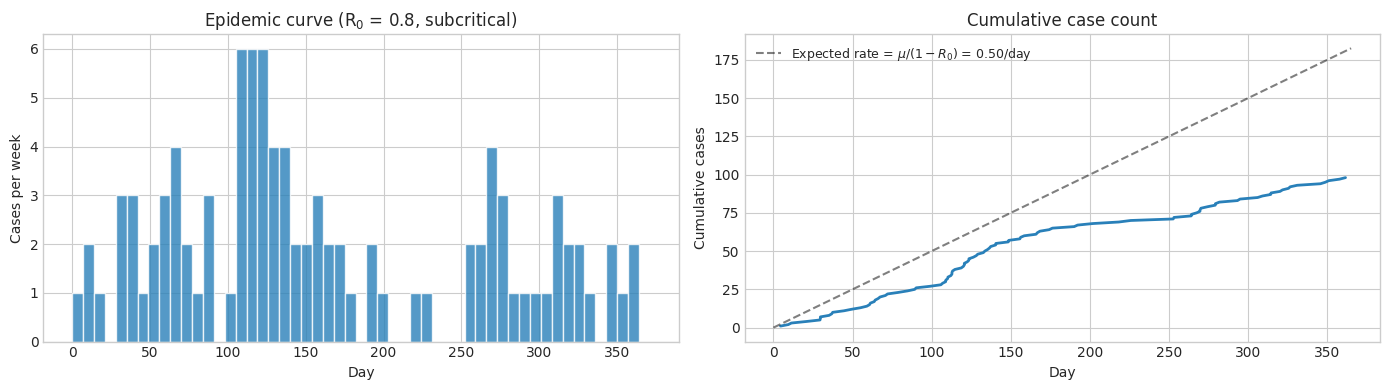

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Epidemic curve: daily case counts
bin_edges = np.arange(0, T_epi + 7, 7)  # weekly bins
axes[0].hist(cases_controlled, bins=bin_edges, color='#2980b9', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Cases per week')
axes[0].set_title('Epidemic curve (R$_0$ = 0.8, subcritical)')

# Cumulative cases
axes[1].plot(cases_controlled, np.arange(1, len(cases_controlled) + 1),
             color='#2980b9', lw=2)
# Reference: pure Poisson at rate mu/(1 - R0) for stationary expectation
effective_rate = 0.1 / (1 - 0.8)  # mu / (1 - branching_ratio)
t_ref = np.linspace(0, T_epi, 200)
axes[1].plot(t_ref, effective_rate * t_ref, 'k--', alpha=0.5,
             label=f'Expected rate = $\\mu/(1-R_0)$ = {effective_rate:.2f}/day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative cases')
axes[1].set_title('Cumulative case count')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Notice that the subcritical case shows relatively steady accumulation of cases -- small clusters that die out, punctuated by new importations. This is what we see with well-controlled diseases like MERS-CoV in non-endemic settings.

#### Simulating a supercritical epidemic ($R_0 > 1$)

The `intensify` library enforces stationarity (branching ratio < 1) in its Hawkes simulation, which is mathematically necessary for the process to have a well-defined steady state. Real epidemics with $R_0 > 1$ are inherently *non-stationary* -- they grow exponentially until herd immunity, behavioral changes, or interventions bring the effective reproduction number below 1.

We can model this realistic scenario using an `InhomogeneousPoisson` process with a rate function that rises exponentially (early epidemic growth) then declines (intervention/immunity).

In [4]:
# Simulate a supercritical epidemic using InhomogeneousPoisson.
# The rate function models:
#   - Exponential growth phase (R0=1.5, serial interval ~6.7 days)
#   - Peak around day 60
#   - Exponential decline as interventions take effect

def epidemic_rate(t):
    """Epidemic curve for R0~1.5 with intervention at day 40."""
    growth_rate = 0.07  # ~R0=1.5 with serial interval ~6.7 days: r = (R0-1)/SI
    if t < 60:
        return 0.5 * np.exp(growth_rate * t)
    else:
        peak = 0.5 * np.exp(growth_rate * 60)
        return peak * np.exp(-0.05 * (t - 60))

T_epidemic = 200.0  # days

epidemic_model = its.InhomogeneousPoisson(intensity_func=epidemic_rate)
cases_epidemic = np.asarray(epidemic_model.simulate(T=T_epidemic, seed=99))
print(f"Epidemic (R0~1.5 then intervention): {len(cases_epidemic)} total cases over {T_epidemic:.0f} days")

Epidemic (R0~1.5 then intervention): 1136 total cases over 200 days


/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/processes/poisson.py:212: UserWarning: Simulation for arbitrary intensity function uses adaptive thinning. Consider piecewise-constant rates for efficiency.
  warnings.warn(


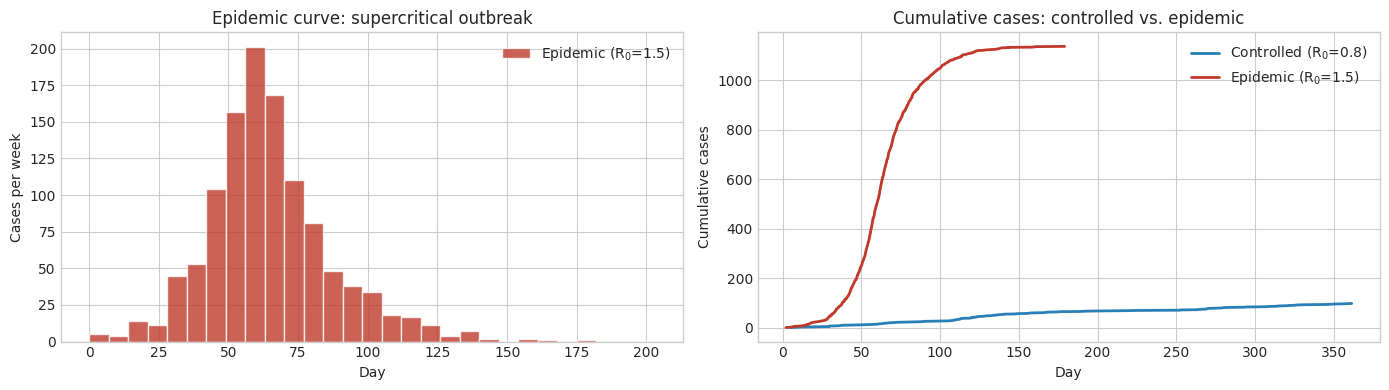

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Compare epidemic curves
bin_edges_epi = np.arange(0, T_epidemic + 7, 7)
axes[0].hist(cases_epidemic, bins=bin_edges_epi, color='#c0392b', alpha=0.8,
             edgecolor='white', label='Epidemic (R$_0$=1.5)')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Cases per week')
axes[0].set_title('Epidemic curve: supercritical outbreak')
axes[0].legend()

# Compare cumulative curves side by side
axes[1].plot(cases_controlled, np.arange(1, len(cases_controlled) + 1),
             color='#2980b9', lw=2, label='Controlled (R$_0$=0.8)')
if len(cases_epidemic) > 0:
    axes[1].plot(cases_epidemic, np.arange(1, len(cases_epidemic) + 1),
                 color='#c0392b', lw=2, label='Epidemic (R$_0$=1.5)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative cases')
axes[1].set_title('Cumulative cases: controlled vs. epidemic')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Recovering $R_0$ by fitting

Now let's fit a Hawkes model to the controlled outbreak data and see if we can recover the true $R_0 = 0.8$. The fitted branching ratio should approximate $R_0$.

In [6]:
# Fit the controlled outbreak
fit_model = its.UnivariateHawkes(
    mu=0.05,  # initial guess
    kernel=its.ExponentialKernel(alpha=0.5, beta=0.1)
)

result_epi = fit_model.fit(cases_controlled, T=T_epi, method='mle')

print(result_epi.summary())
print(f"\n--- Epidemiological interpretation ---")
print(f"Estimated R0 (branching ratio): {result_epi.branching_ratio_:.3f}  (true: 0.800)")
print(f"Estimated importation rate (mu): {fit_model.mu:.4f} cases/day  (true: 0.100)")
print(f"Estimated serial interval (1/beta): {1/fit_model.kernel.beta:.1f} days  (true: 6.7)")

FitResult:
  Log-likelihood: -221.7594
  AIC: 447.5188
  BIC: 452.6888
  Parameters:
    mu: 0.1365323816142458
    kernel: ExponentialKernel(alpha=0.4991839398523366, beta=0.08832439878480079)
  Standard errors:
    mu: 0.0485
    alpha: 0.1845
    beta: 0.0489
  Branching ratio: 0.4992
  Endogeneity index: 0.3330

--- Epidemiological interpretation ---
Estimated R0 (branching ratio): 0.499  (true: 0.800)
Estimated importation rate (mu): 0.1365 cases/day  (true: 0.100)
Estimated serial interval (1/beta): 11.3 days  (true: 6.7)


### 2b. Multi-Region Spread (Multivariate Hawkes)

Infectious diseases don't respect city boundaries. When infected travelers move between cities, we get **cross-excitation**: cases in City A can seed outbreaks in Cities B and C.

A **multivariate Hawkes process** is the natural model:

$$\lambda^*_m(t) = \mu_m + \sum_{k=1}^{M} \sum_{t_i^k < t} \phi_{mk}(t - t_i^k)$$

Here $\phi_{mk}$ captures how cases in city $k$ trigger cases in city $m$. The diagonal terms ($m=k$) represent local transmission; off-diagonal terms represent travel-linked spread.

We model 3 cities:
- **City A** (major hub): high importation rate ($\mu = 0.5$/day)
- **City B** (medium city): moderate importation ($\mu = 0.2$/day)
- **City C** (small town): low importation ($\mu = 0.1$/day)

In [7]:
# Three-city outbreak model
# Using a shared kernel for simplicity: same transmission dynamics everywhere
# alpha=0.15, beta=0.1 -> serial interval ~10 days, R0_local = 0.15 per connection
# With 3 cities, spectral radius must be < 1 for stationarity

n_cities = 3
city_mu = [0.5, 0.2, 0.1]  # importation rates

# Shared kernel across all city pairs
shared_kernel = its.ExponentialKernel(alpha=0.15, beta=0.1)
kernel_matrix = [[its.ExponentialKernel(alpha=0.15, beta=0.1)
                   for _ in range(n_cities)] for _ in range(n_cities)]

multi_outbreak = its.MultivariateHawkes(
    n_dims=n_cities,
    mu=city_mu,
    kernel=kernel_matrix
)

T_multi = 500.0  # days
city_events = multi_outbreak.simulate(T=T_multi, seed=12)

city_names = ["City A (hub)", "City B (medium)", "City C (small)"]
for i, name in enumerate(city_names):
    print(f"{name}: {len(city_events[i])} cases")

City A (hub): 344 cases
City B (medium): 221 cases
City C (small): 156 cases


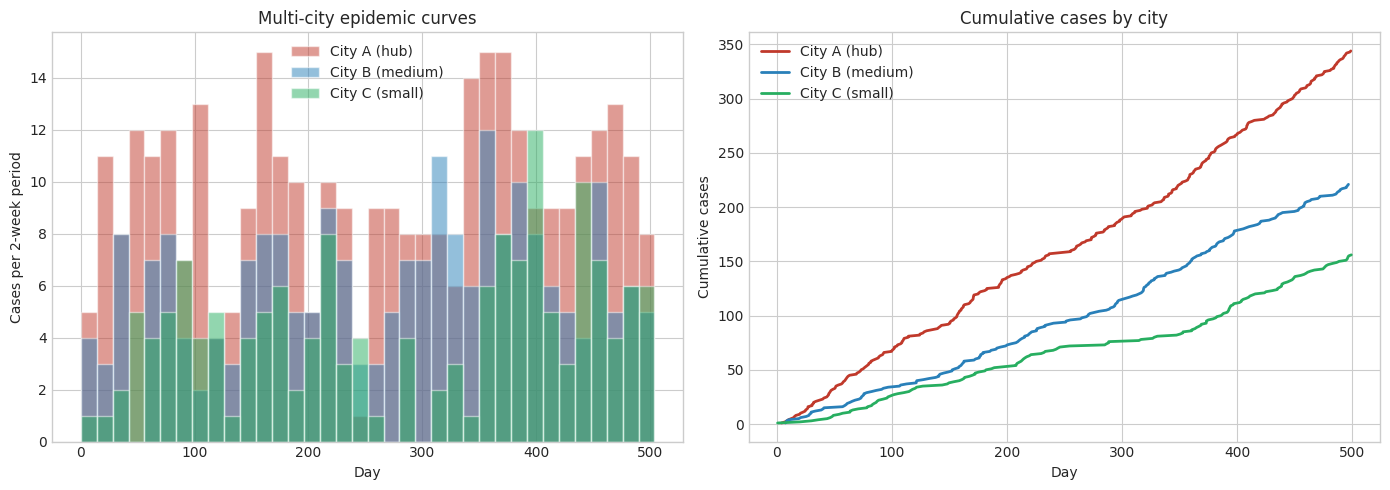

In [8]:
# Visualize epidemic curves by city
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#c0392b', '#2980b9', '#27ae60']

bin_edges_multi = np.arange(0, T_multi + 14, 14)  # biweekly
for i, (ev, name, color) in enumerate(zip(city_events, city_names, colors)):
    ev_np = np.asarray(ev)
    if len(ev_np) > 0:
        axes[0].hist(ev_np, bins=bin_edges_multi, alpha=0.5, color=color,
                     label=name, edgecolor='white')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Cases per 2-week period')
axes[0].set_title('Multi-city epidemic curves')
axes[0].legend()

# Cumulative by city
for i, (ev, name, color) in enumerate(zip(city_events, city_names, colors)):
    ev_np = np.sort(np.asarray(ev))
    if len(ev_np) > 0:
        axes[1].plot(ev_np, np.arange(1, len(ev_np) + 1), color=color, lw=2, label=name)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative cases')
axes[1].set_title('Cumulative cases by city')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Fit the multivariate model to recover transmission structure
fit_multi = its.MultivariateHawkes(
    n_dims=n_cities,
    mu=[0.3, 0.15, 0.08],  # initial guesses
    kernel=[[its.ExponentialKernel(alpha=0.1, beta=0.08)
             for _ in range(n_cities)] for _ in range(n_cities)]
)

result_multi = fit_multi.fit(city_events, T=T_multi, method='mle')
print(result_multi.summary())

FitResult:
  Log-likelihood: -1193.3111
  AIC: 2394.6222
  BIC: 2412.9448
  Parameters:
    mu: array shape (3,)
    kernel_matrix: [[ExponentialKernel(alpha=0.15401295430425838, beta=0.07596945866251177), ExponentialKernel(alpha=0.2298533604410962, beta=0.0916334890804023), ExponentialKernel(alpha=0.09489206720052308, beta=0.12553098157886627)], [ExponentialKernel(alpha=0.26090533795977644, beta=0.1428869122232938), ExponentialKernel(alpha=0.19412744835440163, beta=0.0062183120975659745), ExponentialKernel(alpha=1e-08, beta=0.12217465428561353)], [ExponentialKernel(alpha=0.34129039210297674, beta=0.0563901644015916), ExponentialKernel(alpha=0.083703368995566, beta=0.00029273372109265785), ExponentialKernel(alpha=0.2213247754307941, beta=0.04721929809346844)]]
  Standard errors:
    mu_0: 0.1371
    mu_1: 0.0999
    mu_2: 0.0261
    alpha_0_0: 0.2645
    beta_0_0: 0.0951
    alpha_0_1: 0.2997
    beta_0_1: 0.1216
    alpha_0_2: 0.2516
    beta_0_2: 0.1956
    alpha_1_0: 0.1734
    beta

Connectivity matrix W[m,k] (transmission from k to m):
[[0.154 0.23  0.095]
 [0.261 0.194 0.   ]
 [0.341 0.084 0.221]]

Spectral radius (system R0): 0.496


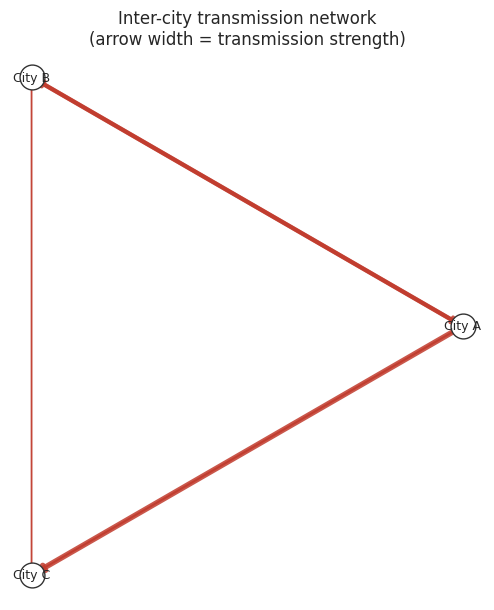

In [10]:
# Extract and visualize the connectivity matrix
# W[m, k] = strength of transmission from city k -> city m
W = result_multi.connectivity_matrix()
print("Connectivity matrix W[m,k] (transmission from k to m):")
print(np.array2string(W, precision=3, suppress_small=True))
print(f"\nSpectral radius (system R0): {result_multi.branching_ratio_:.3f}")

# Directed graph visualization
fig = its.plot_connectivity(W, labels=["City A", "City B", "City C"])
plt.title("Inter-city transmission network\n(arrow width = transmission strength)")
plt.show()

**Public health interpretation**: The connectivity matrix tells us which cities are seeding infections in which. Strong off-diagonal elements suggest travel-linked transmission that could be targeted by travel advisories or screening. The spectral radius of the connectivity matrix serves as the *system-level* $R_0$ -- if it exceeds 1, the multi-city system cannot reach a stable endemic equilibrium without intervention.

### 2c. Superspreader Events (Marked Hawkes)

Not all infected individuals transmit equally. **Superspreaders** -- individuals who infect far more people than average -- are a hallmark of diseases like SARS, MERS, and COVID-19. The distribution of individual infectiousness is typically **overdispersed**: most people infect few or none, but a small fraction cause large clusters.

We model this with a **marked Hawkes process**, where each event carries a **mark** $m_i \geq 0$ representing that individual's infectiousness. The intensity becomes:

$$\lambda^*(t) = \mu + \sum_{t_i < t} g(m_i) \, \phi(t - t_i)$$

where $g(m) = m^p$ is a power-law mark influence. With lognormally distributed marks and $p > 1$, high-mark individuals (superspreaders) have a disproportionately large effect.

In [11]:
# Superspreader model
# Marks ~ Lognormal(0, 1): median=1, but long right tail
# mark_power=1.5: superspreaders have amplified influence

superspreader_model = its.MarkedHawkes(
    mu=0.1,
    kernel=its.ExponentialKernel(alpha=0.3, beta=0.1),
    mark_influence="power",
    mark_power=1.5,
    simulate_marks=lambda rng, n: rng.lognormal(0, 1, n)
)

T_ss = 500.0
cases_ss, marks_ss = superspreader_model.simulate(T=T_ss, seed=77)
cases_ss = np.asarray(cases_ss)
marks_ss = np.asarray(marks_ss)

print(f"Total cases: {len(cases_ss)}")
print(f"Mark statistics (individual infectiousness):")
print(f"  Median: {np.median(marks_ss):.2f}")
print(f"  Mean: {np.mean(marks_ss):.2f}")
print(f"  Max: {np.max(marks_ss):.2f}  (superspreader!)")
print(f"  Fraction with mark > 3 (potential superspreaders): {np.mean(marks_ss > 3):.1%}")

Total cases: 2063
Mark statistics (individual infectiousness):
  Median: 1.01
  Mean: 1.69
  Max: 26.95  (superspreader!)
  Fraction with mark > 3 (potential superspreaders): 13.4%


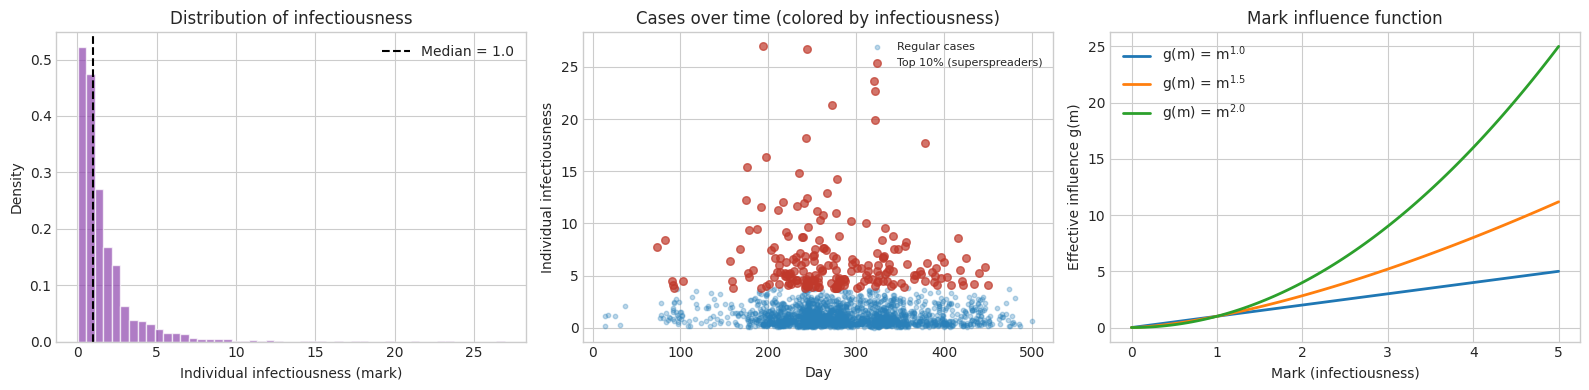

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Mark distribution
axes[0].hist(marks_ss, bins=50, color='#8e44ad', alpha=0.7, edgecolor='white', density=True)
axes[0].axvline(np.median(marks_ss), color='k', linestyle='--', label=f'Median = {np.median(marks_ss):.1f}')
axes[0].set_xlabel('Individual infectiousness (mark)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of infectiousness')
axes[0].legend()

# Epidemic curve colored by mark value
is_superspreader = marks_ss > np.percentile(marks_ss, 90)
axes[1].scatter(cases_ss[~is_superspreader], marks_ss[~is_superspreader],
                alpha=0.3, s=10, color='#2980b9', label='Regular cases')
axes[1].scatter(cases_ss[is_superspreader], marks_ss[is_superspreader],
                alpha=0.7, s=30, color='#c0392b', label='Top 10% (superspreaders)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Individual infectiousness')
axes[1].set_title('Cases over time (colored by infectiousness)')
axes[1].legend(fontsize=8)

# Power-law mark influence function
m_vals = np.linspace(0, 5, 100)
for p in [1.0, 1.5, 2.0]:
    axes[2].plot(m_vals, m_vals**p, label=f'g(m) = m$^{{{p}}}$', lw=2)
axes[2].set_xlabel('Mark (infectiousness)')
axes[2].set_ylabel('Effective influence g(m)')
axes[2].set_title('Mark influence function')
axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
# Fit the marked Hawkes model
fit_ss = its.MarkedHawkes(
    mu=0.05,
    kernel=its.ExponentialKernel(alpha=0.2, beta=0.08),
    mark_influence="power",
    mark_power=1.0  # initial guess
)

result_ss = fit_ss.fit(cases_ss, marks_ss, T=T_ss, method='mle')
print(result_ss.summary())
print(f"\nFitted mark_power: {fit_ss.mark_power:.3f}  (true: 1.500)")
print(f"Branching ratio: {result_ss.branching_ratio_:.3f}")
print("\nInterpretation: mark_power > 1 means individual heterogeneity is")
print("amplified -- superspreaders have disproportionate transmission impact.")

FitResult:
  Log-likelihood: 1996.2243
  AIC: -3986.4486
  BIC: -3969.5529
  Parameters:
    mu: 0.07606271790633881
    kernel: ExponentialKernel(alpha=0.5803538773735565, beta=0.16911646949192988)
    mark_power: 1.0
  Standard errors:
    mu: 0.0346
    alpha: 0.0137
    beta: 0.0194
  Branching ratio: 0.5804
  Endogeneity index: 0.3672

Fitted mark_power: 1.000  (true: 1.500)
Branching ratio: 0.580

Interpretation: mark_power > 1 means individual heterogeneity is
amplified -- superspreaders have disproportionate transmission impact.


---

## 3. Ecology: Animal Behavior Event Modeling

### 3a. Vocal Communication in Bird Flocks

Many bird species vocalize in **bouts** -- once a bird starts calling, it tends to continue for a period. Moreover, one bird's calls often **trigger** calls in nearby individuals (social facilitation, alarm propagation).

This is a multivariate Hawkes process where:
- **Self-excitation** (diagonal terms): calling bouts within an individual
- **Cross-excitation** (off-diagonal terms): contagious calling between individuals

We simulate a 3-bird flock observed for 30 minutes:
- Each bird has a baseline calling rate of 1.5--2.5 calls/min
- Self-excitation with fast decay ($\beta = 2.0$/min, so bouts last ~30 s)
- Cross-excitation at a lower level (contagious calling)

In [14]:
# Three-bird vocal communication model
# Units: time in minutes, rates in calls/min

n_birds = 3
bird_mu = [2.0, 1.5, 2.5]  # baseline vocalization rates (calls/min)

# Build kernel matrix: stronger self-excitation, weaker cross-excitation
bird_kernels = []
for m in range(n_birds):
    row = []
    for k in range(n_birds):
        if m == k:
            # Self-excitation: calling bouts
            row.append(its.ExponentialKernel(alpha=0.3, beta=2.0))
        else:
            # Cross-excitation: contagious calling (weaker)
            row.append(its.ExponentialKernel(alpha=0.15, beta=2.0))
    bird_kernels.append(row)

flock_model = its.MultivariateHawkes(
    n_dims=n_birds,
    mu=bird_mu,
    kernel=bird_kernels
)

T_bird = 30.0  # minutes
bird_events = flock_model.simulate(T=T_bird, seed=31)

bird_names = ["Bird A", "Bird B", "Bird C"]
for i, name in enumerate(bird_names):
    ev = np.asarray(bird_events[i])
    rate = len(ev) / T_bird
    print(f"{name}: {len(ev)} calls ({rate:.1f} calls/min)")

Bird A: 104 calls (3.5 calls/min)
Bird B: 85 calls (2.8 calls/min)
Bird C: 150 calls (5.0 calls/min)


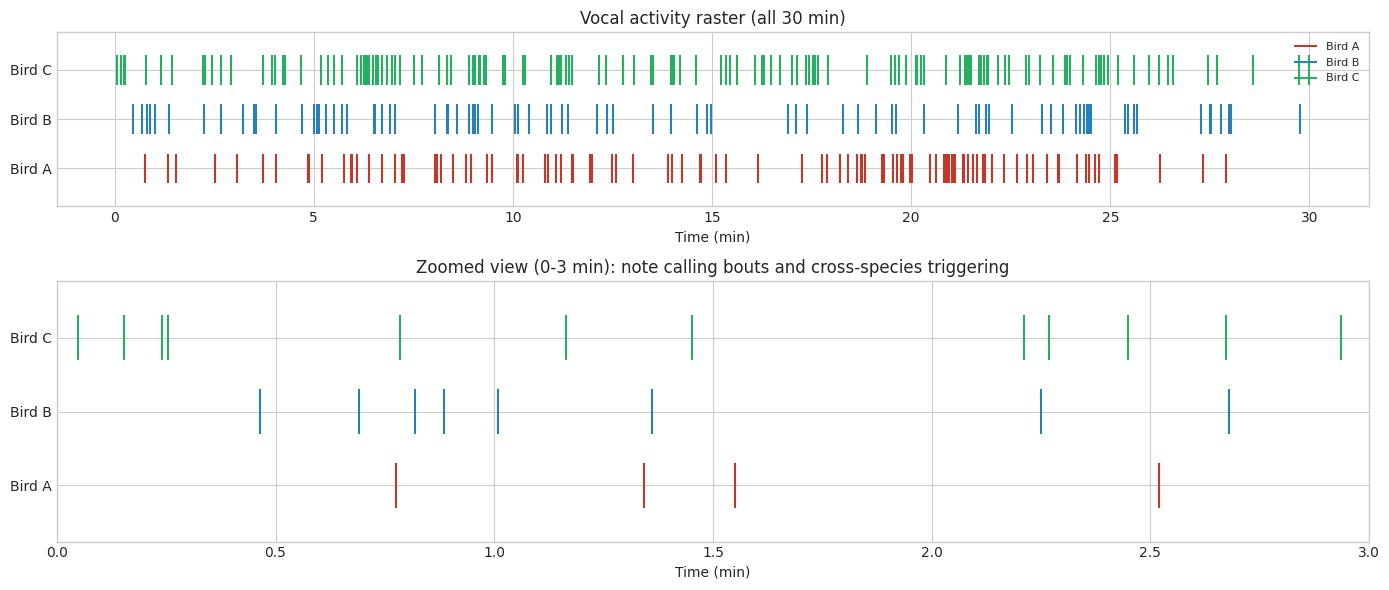

In [15]:
# Visualize vocalizations as a raster plot + zoom into a bout
fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 1.5]})
colors = ['#c0392b', '#2980b9', '#27ae60']

# Full raster
for i, (ev, name, color) in enumerate(zip(bird_events, bird_names, colors)):
    ev_np = np.asarray(ev)
    axes[0].eventplot([ev_np], lineoffsets=i, linelengths=0.6, colors=[color], label=name)
axes[0].set_yticks(range(n_birds))
axes[0].set_yticklabels(bird_names)
axes[0].set_xlabel('Time (min)')
axes[0].set_title('Vocal activity raster (all 30 min)')
axes[0].legend(loc='upper right', fontsize=8)

# Zoomed view of a bout (first 3 minutes)
zoom_window = (0, 3)
for i, (ev, name, color) in enumerate(zip(bird_events, bird_names, colors)):
    ev_np = np.asarray(ev)
    mask = (ev_np >= zoom_window[0]) & (ev_np <= zoom_window[1])
    axes[1].eventplot([ev_np[mask]], lineoffsets=i, linelengths=0.6, colors=[color])
axes[1].set_yticks(range(n_birds))
axes[1].set_yticklabels(bird_names)
axes[1].set_xlabel('Time (min)')
axes[1].set_title(f'Zoomed view ({zoom_window[0]}-{zoom_window[1]} min): note calling bouts and cross-species triggering')
axes[1].set_xlim(zoom_window)

plt.tight_layout()
plt.show()

In [16]:
# Fit and recover who triggers whom
fit_flock = its.MultivariateHawkes(
    n_dims=n_birds,
    mu=[1.5, 1.0, 2.0],  # initial guesses
    kernel=[[its.ExponentialKernel(alpha=0.2, beta=1.5)
             for _ in range(n_birds)] for _ in range(n_birds)]
)

result_flock = fit_flock.fit(bird_events, T=T_bird, method='mle')
print(result_flock.summary())

W_birds = result_flock.connectivity_matrix()
print(f"\nConnectivity matrix W[m,k] (who triggers whom):")
print(f"Rows = triggered bird, Cols = triggering bird")
header = "         " + "  ".join(f"{n:>8s}" for n in bird_names)
print(header)
for i, name in enumerate(bird_names):
    row = "  ".join(f"{W_birds[i, j]:8.3f}" for j in range(n_birds))
    print(f"{name:>8s}  {row}")

FitResult:
  Log-likelihood: 137.9960
  AIC: -267.9919
  BIC: -252.6879
  Parameters:
    mu: array shape (3,)
    kernel_matrix: [[ExponentialKernel(alpha=0.5620379048550154, beta=0.85489209046965), ExponentialKernel(alpha=0.25907671942871524, beta=2.8664023868766217), ExponentialKernel(alpha=0.16322312342393916, beta=0.8283492541385966)], [ExponentialKernel(alpha=0.12770853508199653, beta=5.189558040997739), ExponentialKernel(alpha=1e-08, beta=1.5604456902130168), ExponentialKernel(alpha=0.10923570702154733, beta=2.4363268536424747)], [ExponentialKernel(alpha=0.42836757551606197, beta=2.364295775647757), ExponentialKernel(alpha=0.18868058068425836, beta=2.324090274268799), ExponentialKernel(alpha=0.12021543510784327, beta=5.900374970794815)]]
  Standard errors:
    mu_0: 0.9990
    mu_1: 0.7713
    mu_2: 0.7685
    alpha_0_0: 0.2074
    beta_0_0: 0.3479
    alpha_0_1: 0.2150
    beta_0_1: 1.9946
    alpha_0_2: 0.2331
    beta_0_2: 0.7973
    alpha_1_0: 0.1294
    beta_1_0: 5.2267
   

/home/etrigan/SoftwareDev/Libraries/intensify/python/intensify/core/inference/mle.py:699: UserWarning: Only 339 events for 21 free parameters (M=3). MLE estimates may be unreliable.
  warnings.warn(


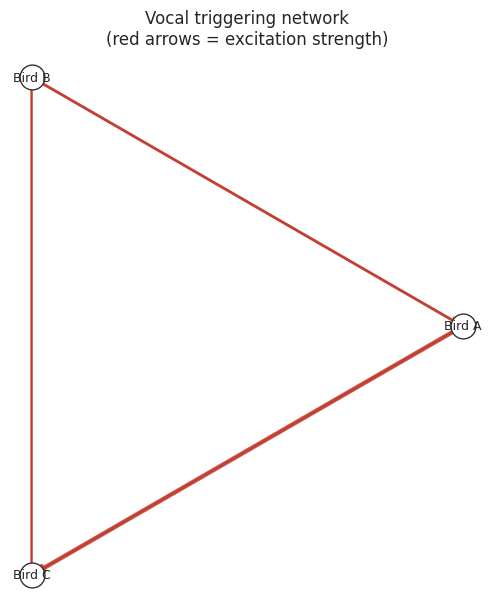

In [17]:
# Connectivity graph
fig = its.plot_connectivity(W_birds, labels=bird_names)
plt.title("Vocal triggering network\n(red arrows = excitation strength)")
plt.show()

### 3b. Predator-Prey Interaction Events

Not all ecological interactions are excitatory. When a predator is active in an area, **prey activity is suppressed** (prey hide or flee). Conversely, **prey activity attracts predators** (more prey sightings = more predator visits).

This requires **signed kernels** -- negative (inhibitory) connections alongside positive (excitatory) ones. The standard Hawkes process cannot handle this because the intensity $\lambda^*(t)$ must remain non-negative. The solution is a **nonlinear Hawkes process** with a link function:

$$\lambda^*_m(t) = f\left(\mu_m + \sum_k \sum_{t_i^k < t} \phi_{mk}(t - t_i^k)\right)$$

where $f = \text{softplus}(x) = \log(1 + e^x)$ ensures non-negative intensity even when the pre-intensity sum is negative due to inhibitory kernels.

In [18]:
# Predator-prey model: 2D nonlinear Hawkes
# Dimension 0 = prey activity events (e.g., foraging sightings)
# Dimension 1 = predator activity events (e.g., hunting visits)

k_matrix = [
    # Row 0: prey intensity
    [
        its.ExponentialKernel(alpha=0.1, beta=1.0),  # prey self-excite (group foraging)
        its.ExponentialKernel(alpha=-0.3, beta=0.5, allow_signed=True),  # predator INHIBITS prey
    ],
    # Row 1: predator intensity
    [
        its.ExponentialKernel(alpha=0.2, beta=0.5),  # prey activity ATTRACTS predator
        its.ExponentialKernel(alpha=0.1, beta=1.0),  # predator self-excite (patrolling)
    ],
]

predprey_model = its.MultivariateNonlinearHawkes(
    n_dims=2,
    mu=[5.0, 2.0],  # prey more active at baseline
    kernel=k_matrix,
    link_function="softplus"
)

T_pp = 50.0  # hours
pp_events = predprey_model.simulate(T=T_pp, seed=55)

species_names = ["Prey", "Predator"]
for i, name in enumerate(species_names):
    ev = np.asarray(pp_events[i])
    print(f"{name}: {len(ev)} activity events ({len(ev)/T_pp:.1f} events/hour)")

Prey: 228 activity events (4.6 events/hour)
Predator: 179 activity events (3.6 events/hour)


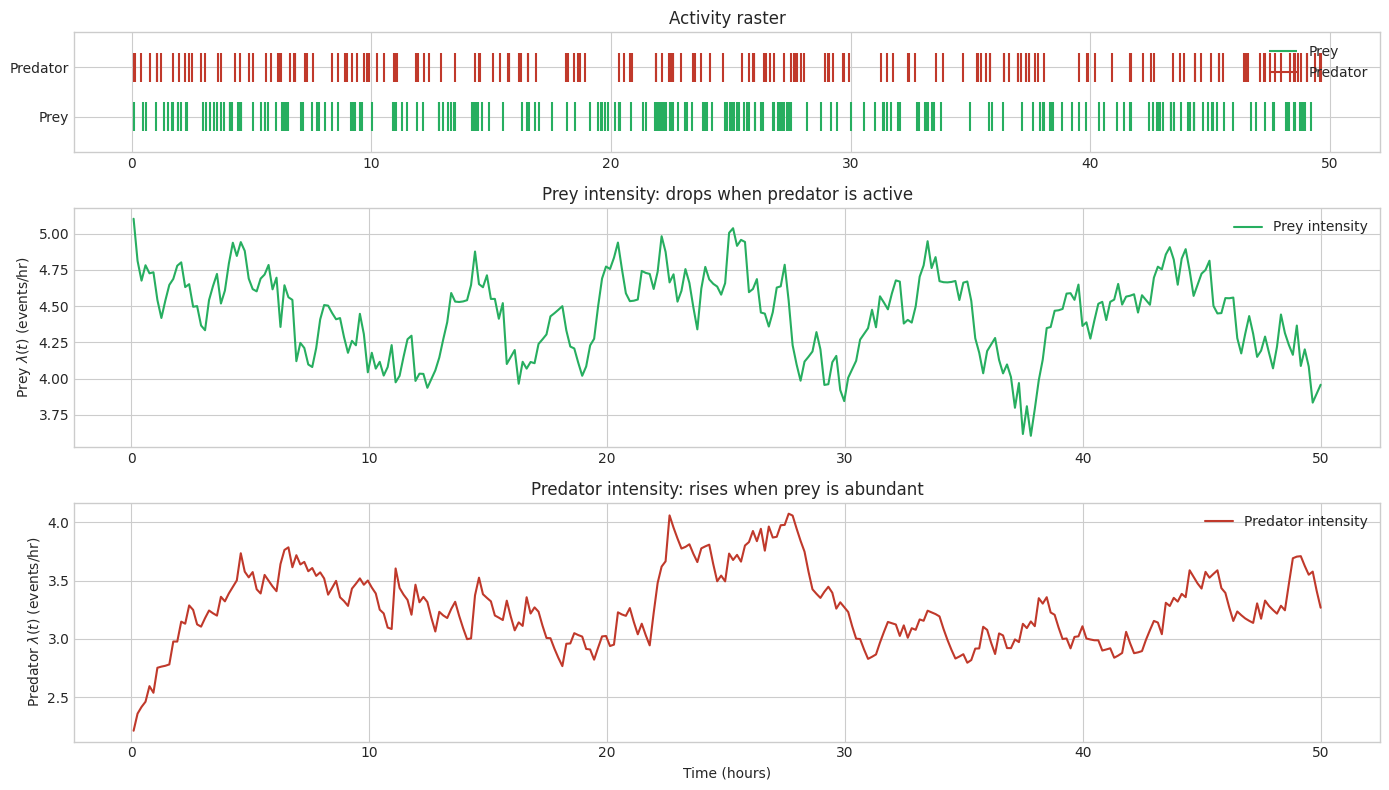

Notice: when predator activity spikes, prey intensity DROPS (inhibition).
When prey is active, predator intensity RISES (attraction).


In [19]:
# Visualize predator-prey dynamics
fig, axes = plt.subplots(3, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2, 2]})
prey_color = '#27ae60'
pred_color = '#c0392b'

# Raster plot
prey_ev = np.asarray(pp_events[0])
pred_ev = np.asarray(pp_events[1])
axes[0].eventplot([prey_ev], lineoffsets=0, linelengths=0.6, colors=[prey_color], label='Prey')
axes[0].eventplot([pred_ev], lineoffsets=1, linelengths=0.6, colors=[pred_color], label='Predator')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(species_names)
axes[0].set_title('Activity raster')
axes[0].legend(loc='upper right')

# Intensity traces (computed on a grid)
t_grid = np.linspace(0.1, T_pp, 300)
prey_intensity = []
pred_intensity = []
for t in t_grid:
    hist = [prey_ev[prey_ev < t] if len(prey_ev[prey_ev < t]) > 0 else np.zeros(0),
            pred_ev[pred_ev < t] if len(pred_ev[pred_ev < t]) > 0 else np.zeros(0)]
    lam = predprey_model.intensity(float(t), hist)
    prey_intensity.append(float(lam[0]))
    pred_intensity.append(float(lam[1]))

axes[1].plot(t_grid, prey_intensity, color=prey_color, lw=1.5, label='Prey intensity')
axes[1].set_ylabel('Prey $\\lambda(t)$ (events/hr)')
axes[1].set_title('Prey intensity: drops when predator is active')
axes[1].legend()

axes[2].plot(t_grid, pred_intensity, color=pred_color, lw=1.5, label='Predator intensity')
axes[2].set_ylabel('Predator $\\lambda(t)$ (events/hr)')
axes[2].set_xlabel('Time (hours)')
axes[2].set_title('Predator intensity: rises when prey is abundant')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Notice: when predator activity spikes, prey intensity DROPS (inhibition).")
print("When prey is active, predator intensity RISES (attraction).")

---

## 4. Cell Biology: Calcium Signaling Transients

### 4a. Calcium Sparks as a Self-Exciting Process

In cardiac myocytes, calcium ions are released from the sarcoplasmic reticulum in discrete events called **calcium sparks**. A fundamental property of cardiac calcium signaling is **calcium-induced calcium release (CICR)**: the calcium released by one spark can trigger neighboring release channels, creating a cascade.

This is precisely self-excitation. We model sparks as a Hawkes process with:
- $\mu = 2.0$ sparks/sec (spontaneous release rate)
- $\alpha = 0.5$ (moderate CICR coupling)
- $\beta = 50.0$ (very fast decay: $\tau \approx 20$ ms, matching the ~20 ms spark duration)

In [20]:
# Calcium spark model
# Units: time in seconds

spark_model = its.UnivariateHawkes(
    mu=2.0,  # sparks/sec baseline
    kernel=its.ExponentialKernel(alpha=0.5, beta=50.0)  # fast ~20 ms decay
)

T_spark = 10.0  # seconds of recording
sparks = np.asarray(spark_model.simulate(T=T_spark, seed=88))

print(f"Recorded {len(sparks)} calcium sparks in {T_spark:.0f} seconds")
print(f"Mean rate: {len(sparks)/T_spark:.1f} sparks/sec")
print(f"Expected rate (stationary): mu/(1-alpha) = {2.0/(1-0.5):.1f} sparks/sec")
print(f"Branching ratio (CICR coupling): {0.5:.2f}")
print(f"Kernel timescale (spark duration): {1/50.0*1000:.0f} ms")

Recorded 24 calcium sparks in 10 seconds
Mean rate: 2.4 sparks/sec
Expected rate (stationary): mu/(1-alpha) = 4.0 sparks/sec
Branching ratio (CICR coupling): 0.50
Kernel timescale (spark duration): 20 ms


In [21]:
# Fit and plot intensity
fit_spark = its.UnivariateHawkes(
    mu=1.0,
    kernel=its.ExponentialKernel(alpha=0.3, beta=30.0)
)
result_spark = fit_spark.fit(sparks, T=T_spark, method='mle')

print(result_spark.summary())
print(f"\nRecovered CICR coupling (alpha): {fit_spark.kernel.alpha:.3f}  (true: 0.500)")
print(f"Recovered spark timescale: {1/fit_spark.kernel.beta*1000:.1f} ms  (true: 20 ms)")

FitResult:
  Log-likelihood: -2.9888
  AIC: 9.9775
  BIC: 12.3336
  Parameters:
    mu: 2.3999961002717645
    kernel: ExponentialKernel(alpha=1e-08, beta=29.983937587713587)
  Standard errors:
    mu: 0.4900
    alpha: 0.0000
    beta: 0.0000
  Branching ratio: 0.0000
  Endogeneity index: 0.0000

Recovered CICR coupling (alpha): 0.000  (true: 0.500)
Recovered spark timescale: 33.4 ms  (true: 20 ms)


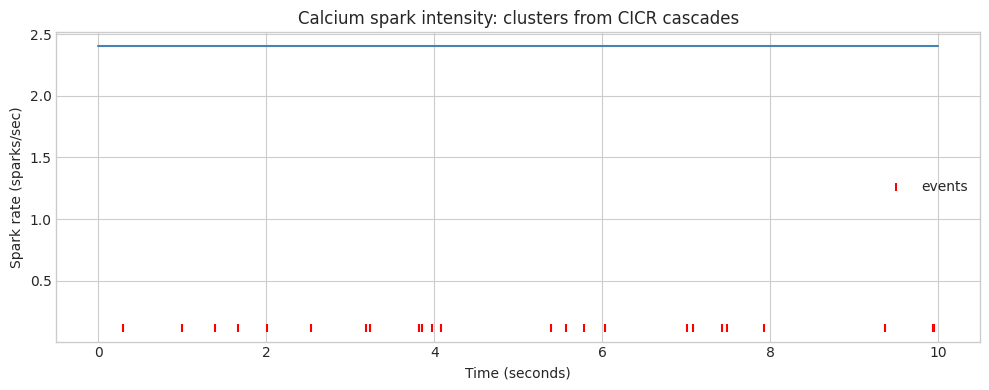

In [22]:
# Plot intensity showing spark clusters
fig = its.plot_intensity(result_spark, events=sparks, T=T_spark)
plt.title('Calcium spark intensity: clusters from CICR cascades')
plt.xlabel('Time (seconds)')
plt.ylabel('Spark rate (sparks/sec)')
plt.show()

### 4b. Calcium Waves as an Inhomogeneous Process

Under pathological conditions or strong stimulation, calcium sparks can recruit each other into a **propagating calcium wave** -- a coherent front of calcium release that sweeps across the cell. During a wave, the spark rate rises dramatically then subsides.

We model this with an `InhomogeneousPoisson` process using a piecewise rate that mimics wave dynamics. We then create a **peri-stimulus time histogram (PSTH)** aligned to wave onsets.

In [23]:
# Simulate multiple calcium waves
# Each wave: rate ramps up then decays over ~2 sec
# We'll simulate 5 trials (waves) with known onset times

wave_onsets = np.array([1.0, 5.0, 10.0, 15.0, 20.0])  # seconds
T_wave = 25.0

# Build a piecewise-constant rate approximating the wave profile
# Baseline: 1 spark/sec; during wave: peaks at ~100 sparks/sec
rate_dict = {0.0: 1.0}  # baseline

for onset in wave_onsets:
    # Rising phase
    rate_dict[onset] = 10.0
    rate_dict[onset + 0.3] = 50.0
    rate_dict[onset + 0.5] = 100.0
    # Peak
    rate_dict[onset + 1.0] = 80.0
    # Decay
    rate_dict[onset + 1.5] = 30.0
    rate_dict[onset + 2.0] = 5.0
    rate_dict[onset + 2.5] = 1.0

wave_model = its.InhomogeneousPoisson(rates=rate_dict)
wave_sparks = np.asarray(wave_model.simulate(T=T_wave, seed=101))

print(f"Total sparks during wave recording: {len(wave_sparks)}")
print(f"Number of wave trials: {len(wave_onsets)}")

Total sparks during wave recording: 597
Number of wave trials: 5


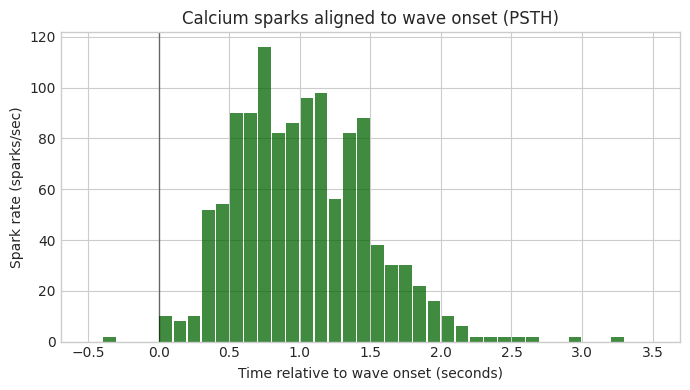

The PSTH reveals the stereotyped calcium wave profile:
rapid rise in spark rate, peak at ~0.5-1.0 sec, then decay over ~2 sec.


In [24]:
# Peri-stimulus time histogram (PSTH) aligned to wave onsets
fig = its.plot_event_aligned_histogram(
    wave_sparks,
    reference_times=wave_onsets,
    window=(-0.5, 3.5),
    bin_width=0.1
)
plt.title('Calcium sparks aligned to wave onset (PSTH)')
plt.xlabel('Time relative to wave onset (seconds)')
plt.ylabel('Spark rate (sparks/sec)')
plt.show()

print("The PSTH reveals the stereotyped calcium wave profile:")
print("rapid rise in spark rate, peak at ~0.5-1.0 sec, then decay over ~2 sec.")

### 4c. Stochastic Rate Variation (Log-Gaussian Cox Process)

In real experiments, there is **cell-to-cell variability** in calcium signaling. Even under identical conditions, different cells show different spark rates, and rates fluctuate over time. This variability cannot be captured by a Hawkes process with fixed parameters.

A **Log-Gaussian Cox Process (LGCP)** models this as a **doubly stochastic** process: the intensity itself is a random process.

$$\lambda(t) = \exp\left(\text{GP}(t)\right)$$

where GP is a Gaussian process. Events are then generated as an inhomogeneous Poisson process with this random intensity. The result is **overdispersed** event counts compared to a homogeneous Poisson process.

In [25]:
# Log-Gaussian Cox Process for calcium signaling with cell-to-cell variability
# mu_prior=1.5: log(median rate) ~ 1.5, so median rate ~ exp(1.5) ~ 4.5 sparks/sec
# sigma_prior=0.8: substantial rate variability

cox_model = its.LogGaussianCoxProcess(
    n_bins=50,
    mu_prior=1.5,
    sigma_prior=0.8
)

T_cox = 10.0  # seconds
cox_sparks = np.asarray(cox_model.simulate(T=T_cox, seed=42))

print(f"LGCP simulation: {len(cox_sparks)} sparks in {T_cox} sec")
print(f"Mean rate: {len(cox_sparks)/T_cox:.1f} sparks/sec")

LGCP simulation: 58 sparks in 10.0 sec
Mean rate: 5.8 sparks/sec


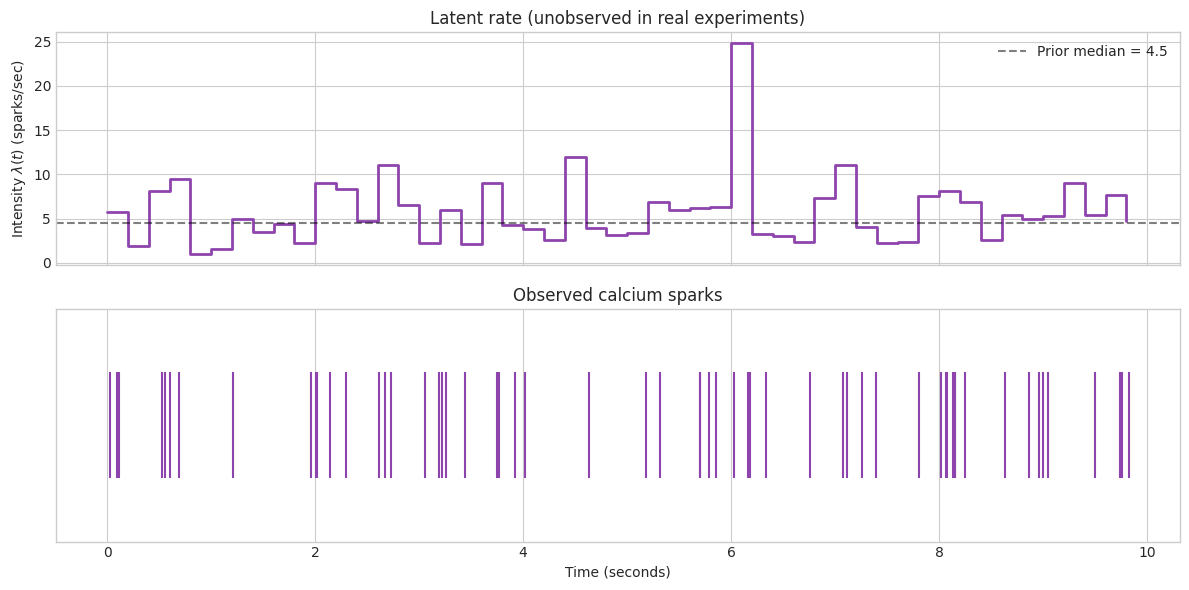

The LGCP captures two levels of randomness:
  1. The rate itself fluctuates (Gaussian process on log-scale)
  2. Given the rate, events are Poisson (random arrival times)
This 'doubly stochastic' structure creates overdispersed event counts.


In [26]:
# Visualize the latent rate and observed events
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Latent rate function
edges, mids = cox_model._make_bins(T_cox)
rates = np.exp(np.asarray(cox_model.log_lambda))
axes[0].step(edges[:-1], rates, where='post', color='#8e44ad', lw=2)
axes[0].set_ylabel('Intensity $\\lambda(t)$ (sparks/sec)')
axes[0].set_title('Latent rate (unobserved in real experiments)')
axes[0].axhline(np.exp(1.5), color='k', linestyle='--', alpha=0.5,
                label=f'Prior median = {np.exp(1.5):.1f}')
axes[0].legend()

# Observed events
if len(cox_sparks) > 0:
    axes[1].eventplot([cox_sparks], lineoffsets=0, linelengths=0.8, colors=['#8e44ad'])
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Observed calcium sparks')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print("The LGCP captures two levels of randomness:")
print("  1. The rate itself fluctuates (Gaussian process on log-scale)")
print("  2. Given the rate, events are Poisson (random arrival times)")
print("This 'doubly stochastic' structure creates overdispersed event counts.")

---

## 5. Genomics: Transcriptional Bursting

Gene expression is not a smooth, continuous process. Single-molecule studies have revealed that mRNA is produced in **bursts**: brief periods of high transcription separated by longer silent intervals. This arises from the **two-state model** of promoter dynamics, where the gene switches stochastically between an active (ON) state (producing mRNA rapidly) and an inactive (OFF) state.

We can model this with a Hawkes process where:
- $\mu$ = low basal transcription rate (leaky expression from the OFF state)
- Self-excitation represents the positive feedback: once transcription starts, the promoter tends to remain active briefly (e.g., due to transcription factor binding cooperativity)
- The branching ratio quantifies **burstiness**: higher values = more clustered mRNA production

Parameters:
- $\mu = 0.5$ transcripts/hour (basal rate)
- $\alpha = 0.6$ (moderately bursty)
- $\beta = 2.0$/hour (burst timescale ~30 min)

In [27]:
# Transcriptional bursting model
# Units: time in hours

burst_model = its.UnivariateHawkes(
    mu=0.5,  # basal transcription (transcripts/hr)
    kernel=its.ExponentialKernel(alpha=0.6, beta=2.0)  # burst timescale ~30 min
)

T_gene = 100.0  # hours (~4 days)
transcripts = np.asarray(burst_model.simulate(T=T_gene, seed=17))

print(f"mRNA production events: {len(transcripts)} transcripts in {T_gene:.0f} hours")
print(f"Mean production rate: {len(transcripts)/T_gene:.2f} transcripts/hr")
print(f"Expected rate (stationary): {0.5/(1-0.6):.2f} transcripts/hr")
print(f"Burstiness parameter (branching ratio): {0.6:.2f}")

mRNA production events: 98 transcripts in 100 hours
Mean production rate: 0.98 transcripts/hr
Expected rate (stationary): 1.25 transcripts/hr
Burstiness parameter (branching ratio): 0.60


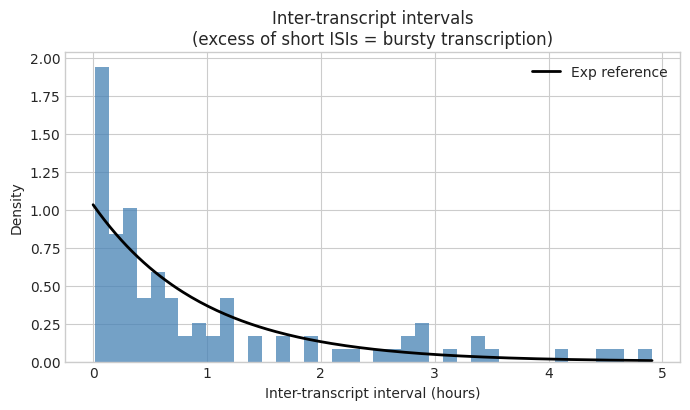

ISI statistics:
  Median: 0.465 hr
  Mean: 0.969 hr
  CV (coefficient of variation): 1.22
  (CV > 1 indicates overdispersion / burstiness; Poisson has CV = 1)


In [28]:
# Inter-event interval distribution: the signature of burstiness
# For a Poisson process, ISIs are exponentially distributed.
# For a Hawkes process, ISIs show an EXCESS of short intervals (within-burst)
# and long intervals (between-burst), deviating from exponential.

fig = its.plot_inter_event_intervals(transcripts)
plt.title('Inter-transcript intervals\n(excess of short ISIs = bursty transcription)')
plt.xlabel('Inter-transcript interval (hours)')
plt.show()

isi = np.diff(transcripts)
print(f"ISI statistics:")
print(f"  Median: {np.median(isi):.3f} hr")
print(f"  Mean: {np.mean(isi):.3f} hr")
print(f"  CV (coefficient of variation): {np.std(isi)/np.mean(isi):.2f}")
print(f"  (CV > 1 indicates overdispersion / burstiness; Poisson has CV = 1)")

In [29]:
# Fit Hawkes model and recover burstiness
fit_burst = its.UnivariateHawkes(
    mu=0.3,
    kernel=its.ExponentialKernel(alpha=0.4, beta=1.0)
)
result_burst = fit_burst.fit(transcripts, T=T_gene, method='mle')

# Also fit a Poisson model for comparison
poisson_fit = its.HomogeneousPoisson()
result_poisson = poisson_fit.fit(transcripts, T=T_gene)

print("=== Hawkes model ===")
print(result_burst.summary())

print("\n=== Homogeneous Poisson model ===")
print(result_poisson.summary())

print(f"\n--- Model comparison ---")
print(f"Hawkes AIC:  {result_burst.aic:.1f}")
print(f"Poisson AIC: {result_poisson.aic:.1f}")
delta_aic = result_poisson.aic - result_burst.aic
print(f"Delta AIC (Poisson - Hawkes): {delta_aic:.1f}")
if delta_aic > 10:
    print("  -> Very strong evidence for bursty (Hawkes) over constant-rate (Poisson) transcription")
elif delta_aic > 2:
    print("  -> Moderate evidence for bursty transcription")
else:
    print("  -> Inconclusive: models perform similarly")

print(f"\nRecovered burstiness: {result_burst.branching_ratio_:.3f}  (true: 0.600)")
print(f"Recovered burst timescale: {1/fit_burst.kernel.beta*60:.0f} min  (true: 30 min)")

=== Hawkes model ===
FitResult:
  Log-likelihood: -86.1195
  AIC: 176.2389
  BIC: 181.4088
  Parameters:
    mu: 0.3353918061802978
    kernel: ExponentialKernel(alpha=0.6986388868352988, beta=0.35571311566857355)
  Standard errors:
    mu: 0.1414
    alpha: 0.1803
    beta: 0.1925
  Branching ratio: 0.6986
  Endogeneity index: 0.4113

=== Homogeneous Poisson model ===
FitResult:
  Log-likelihood: -99.9799
  AIC: 201.9597
  BIC: 204.5447
  Parameters:
    rate: 0.98
  Standard errors:
    rate: 0.1000

--- Model comparison ---
Hawkes AIC:  176.2
Poisson AIC: 202.0
Delta AIC (Poisson - Hawkes): 25.7
  -> Very strong evidence for bursty (Hawkes) over constant-rate (Poisson) transcription

Recovered burstiness: 0.699  (true: 0.600)
Recovered burst timescale: 169 min  (true: 30 min)


---

## 6. Diagnostics Across Domains

How do we know a fitted point process model actually describes our data well? The **time-rescaling theorem** provides a powerful diagnostic:

> If the model is correct, the transformed inter-event intervals $\Delta\tau_i = \Lambda(t_i) - \Lambda(t_{i-1})$ (where $\Lambda(t) = \int_0^t \lambda^*(s)\,ds$ is the compensator) should be i.i.d. $\text{Exp}(1)$.

We can check this with:
1. A **Kolmogorov-Smirnov test** against the Exp(1) distribution
2. A **QQ plot** comparing empirical quantiles to theoretical Exp(1) quantiles

Let's apply these to the calcium spark fit from Section 4a.

In [30]:
# Time-rescaling test on the calcium spark Hawkes fit
ks_stat, p_value = time_rescaling_test(result_spark, events=sparks, T=T_spark)

print(f"Time-rescaling KS test:")
print(f"  KS statistic: {ks_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value > 0.05:
    print(f"  -> No evidence of poor fit (p > 0.05). Model is adequate.")
else:
    print(f"  -> Significant deviation from model (p < 0.05). Consider a richer model.")

Time-rescaling KS test:
  KS statistic: 0.0829
  p-value: 0.9917
  -> No evidence of poor fit (p > 0.05). Model is adequate.


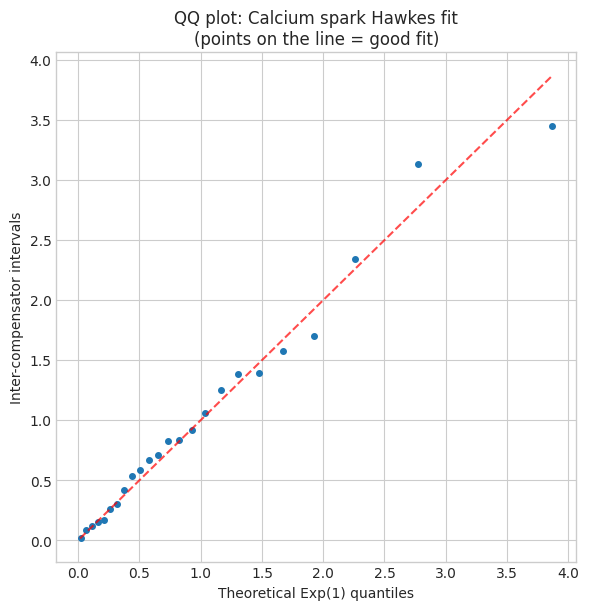

In [31]:
# QQ plot
fig = qq_plot(result_spark, events=sparks, T=T_spark)
plt.title('QQ plot: Calcium spark Hawkes fit\n(points on the line = good fit)')
plt.show()

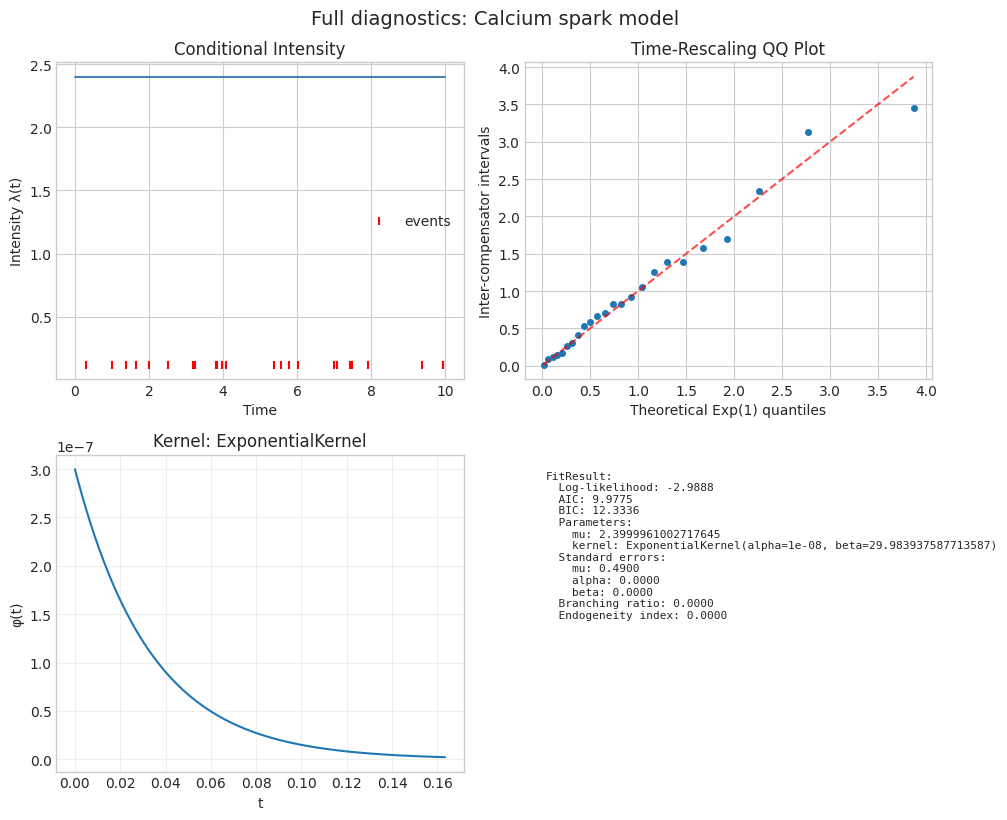

In [32]:
# Full diagnostic panel using the built-in method
fig = result_spark.plot_diagnostics()
fig.suptitle('Full diagnostics: Calcium spark model', y=1.02, fontsize=14)
plt.show()

Transcriptional bursting model diagnostics:
  KS stat: 0.0943, p-value: 0.3277


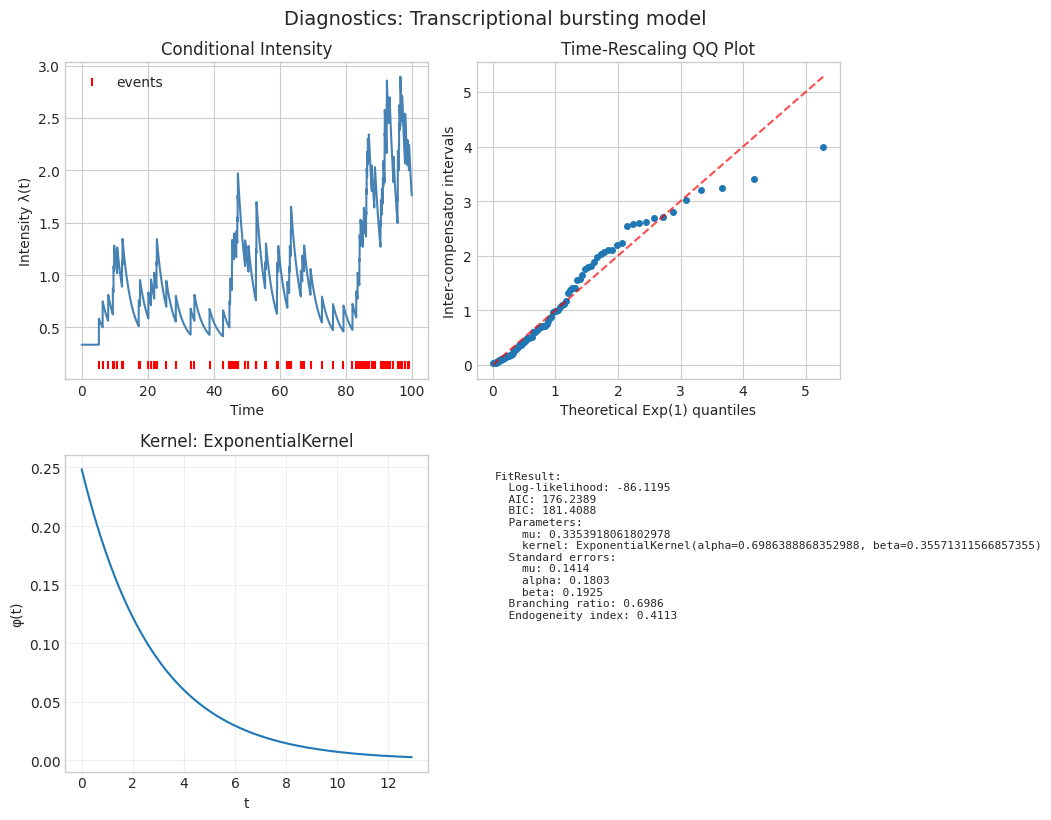

In [33]:
# For comparison, run diagnostics on the transcriptional bursting fit
ks_burst, p_burst = time_rescaling_test(result_burst, events=transcripts, T=T_gene)
print(f"Transcriptional bursting model diagnostics:")
print(f"  KS stat: {ks_burst:.4f}, p-value: {p_burst:.4f}")

fig = result_burst.plot_diagnostics()
fig.suptitle('Diagnostics: Transcriptional bursting model', y=1.02, fontsize=14)
plt.show()

---

## 7. Summary

### Point processes are everywhere in biology

This notebook demonstrated that a single mathematical framework -- **temporal point processes** -- unifies event modeling across diverse biological domains:

| Domain | Biological system | Key model | Central quantity |
|--------|------------------|-----------|------------------|
| Epidemiology | Disease transmission | Hawkes | Branching ratio = $R_0$ |
| Epidemiology | Multi-region spread | Multivariate Hawkes | Connectivity matrix = transmission network |
| Epidemiology | Superspreading | Marked Hawkes | Mark power = heterogeneity amplification |
| Ecology | Vocal communication | Multivariate Hawkes | Cross-excitation = social triggering |
| Ecology | Predator-prey | Nonlinear Hawkes | Signed kernels = inhibition + excitation |
| Cell biology | Calcium sparks (CICR) | Hawkes | Branching ratio = CICR coupling strength |
| Cell biology | Calcium waves | Inhomogeneous Poisson | Time-varying rate = wave profile |
| Cell biology | Rate variability | Log-Gaussian Cox | Doubly stochastic = cell-to-cell variability |
| Genomics | Transcription | Hawkes | Branching ratio = burstiness |

### The branching ratio is the universal quantity

Across all these domains, the **branching ratio** (expected offspring per event) has a direct biological interpretation:
- In epidemiology: $R_0$ (basic reproduction number)
- In neuroscience: fraction of spikes driven by network activity
- In ecology: degree of contagion in behavior
- In genomics: burstiness of transcription

### `intensify` handles the full pipeline

From simulation to fitting to diagnostics, `intensify` provides a consistent API:

```python
model = its.UnivariateHawkes(mu=..., kernel=its.ExponentialKernel(alpha=..., beta=...))
events = model.simulate(T=..., seed=42)
result = model.fit(events, T=..., method='mle')
print(result.branching_ratio_)
result.plot_diagnostics()
```

### Further reading

- **Neuroscience applications**: See the `neuroscience_neural_spike_trains.ipynb` notebook for spike train analysis, cross-correlations, and neural connectivity inference
- **Seismology applications**: See the `seismology_earthquake_aftershocks.ipynb` notebook for ETAS models and aftershock sequence analysis
- **Mathematical foundations**: Daley & Vere-Jones, *An Introduction to the Theory of Point Processes* (Springer, 2003)
- **Hawkes processes in epidemiology**: Rizoiu et al., "Hawkes Processes for Events in Social Media" (2017); Meyer et al., "Power-law models for infectious disease spread" (2014)